In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/My Drive/Colab Notebooks')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
from scipy.io.arff import loadarff
import torch

In [ ]:
train_path="Data/ECG200_TRAIN.arff"
test_path="Data/ECG200_TEST.arff"
def read_ariff(path):
    raw_data, meta =loadarff(path)
    cols=[x for x in meta]
    data2d=np.zeros([raw_data.shape[0],len(cols)])
    for i,col in zip(range(len(cols)),cols):
        data2d[:,i]=raw_data[col]
    print(data2d.shape)
    return data2d

data2d=read_ariff(train_path)
test2d=read_ariff(test_path)
print(data2d.shape, test2d.shape)

(100, 97)
(100, 97)
(100, 97) (100, 97)


In [ ]:
# Get the number of columns
cols = data2d.shape[1]

# Split the data
train_x = data2d[:, :cols-1]  # All columns except the last one
data_for_spike = train_x
train_y = data2d[:, cols-1]   # The last column

train_y[np.where(train_y != 1)] = 0

In [ ]:
import pandas as pd

# Load the CSV file
file_path1 = 'Data/ECG200_results_regression4.csv'
df2 = pd.read_csv(file_path1, header=None)

# Convert the DataFrame to a 2D NumPy array
numpy_array = df2.to_numpy()

# Get the number of rows and columns
numpy_array.shape

(1600, 97)

In [ ]:
reshaped_array = numpy_array.reshape(int(numpy_array.shape[0]/16), 16, numpy_array.shape[1])
tensor = torch.tensor(reshaped_array, dtype=torch.float32)

# Verify the new tensor shape
print(f"tensor.shape is: {tensor.shape}")

tensor.shape is: torch.Size([100, 16, 97])


In [ ]:
#y_tensor = torch.tensor(train_y, dtype=torch.float32)

In [ ]:
#y_expanded = y_tensor.unsqueeze(1).expand(-1, 16)  # shape becomes [100, 16]

# Then, assign this to the last column (dim=2, index 96)
#tensor[:, :, -1] = y_expanded

In [ ]:
tensor.shape

torch.Size([100, 16, 97])

In [ ]:
# Generate a random permutation of indices
indices = torch.randperm(tensor.shape[0])  # shape[0] = 100

# Shuffle x_tensor using these indices
x_tensor_shuffled = tensor[indices]

In [ ]:
torch.save(indices, 'indices.pt')

In [ ]:
print(f"y_tensor.shape is: {y_tensor.shape}")

y_tensor.shape is: torch.Size([100])


In [ ]:
tensor = x_tensor_shuffled

In [ ]:
split_index = int(0.7 * tensor.shape[0])  # 80% of 861 → 688.8 → 689

train_tensor = tensor[:split_index]   # [689, 16, 137]
test_tensor = tensor[split_index:]    # [172, 16, 137]

# Print shapes to verify
print(train_tensor.shape)  # torch.Size([689, 16, 137])
print(test_tensor.shape)   # torch.Size([172, 16, 137])

torch.Size([70, 16, 97])
torch.Size([30, 16, 97])


In [ ]:
num_timesteps = tensor.shape[2]-1

In [ ]:
# Split the tensor into two parts
tensor_first = train_tensor[:, :, :num_timesteps]  # Contains the first 152 columns
tensor_last_column = train_tensor[:, :, num_timesteps]  # Contains the last column
tensor_last_column_reduced = tensor_last_column[:, 0]
train_x = tensor_first
train_y = tensor_last_column_reduced




In [ ]:
# Split the tensor into two parts
test_tensor_first = test_tensor[:, :, :num_timesteps]  # Contains the first 152 columns
test_tensor_last_column = test_tensor[:, :, num_timesteps]  # Contains the last column
test_tensor_last_column_reduced = test_tensor_last_column[:, 0]
test_x = test_tensor_first
test_y = test_tensor_last_column_reduced

In [ ]:
import torch

# Assuming final_output is your stacked tensor of 0s and 1s
percentage_ones = (train_x.sum().item() / train_x.numel()) * 100

print(f"Percentage of 1s: {percentage_ones:.2f}%")

Percentage of 1s: 5.07%


In [ ]:
# Split the tensor into two parts
#test_tensor_first = test_tensor[:, :, :num_timesteps]  # Contains the first timestep columns
#test_tensor_last_column = test_tensor[:, :, num_timesteps]  # Contains the last column

#test_x = test_tensor_first


In [ ]:
#train_y = y_tensor[:split_index]   # [689, 16, 137]
#test_y = y_tensor[split_index:]

In [ ]:
test_y.shape

torch.Size([30])

# Cross Entropy


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Sample dimensions

d = 8
n = num_timesteps
input_dim = 2 * d * n  # Flattened input size (16 * 96)


#train_x = torch.randn(batch_size, 2 * d, n)  # Shape: (999, 16, 152)
train_x = train_x.float()
#train_y = torch.randint(0, 2, (batch_size,))  # Binary labels for two classes
# Convert train_y from numpy array to torch tensor
train_y_tensor = torch.tensor(train_y, dtype=torch.long)  # Ensure the correct dtype for classification

# Define the model
class Classifier(nn.Module):
    def __init__(self, input_dim):
        super(Classifier, self).__init__()
        self.fc = nn.Linear(input_dim, 2)  # Fully connected layer for 2 classes

    def forward(self, x):
        #x = x.view(x.size(0), -1)  # Flatten 2*d x n to (batch_size, 2*d*n)
        x = x.reshape(x.size(0), -1)  # Flatten 2*d x n to (batch_size, 2*d*n)
        return self.fc(x)

# Instantiate the model
model = Classifier(input_dim)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()  # Use CrossEntropyLoss for binary classification
optimizer = optim.Adam(model.parameters(), lr=0.05, weight_decay=0.01)

# Training loop
num_epochs = 40
for epoch in range(num_epochs):
    model.train()

    # Forward pass
    outputs = model(train_x)
    loss = criterion(outputs, train_y_tensor)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print loss
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/40], Loss: 0.6719
Epoch [2/40], Loss: 0.9597
Epoch [3/40], Loss: 0.3949
Epoch [4/40], Loss: 0.2531
Epoch [5/40], Loss: 0.3070
Epoch [6/40], Loss: 0.2316
Epoch [7/40], Loss: 0.0913
Epoch [8/40], Loss: 0.0260
Epoch [9/40], Loss: 0.0239
Epoch [10/40], Loss: 0.0372
Epoch [11/40], Loss: 0.0455
Epoch [12/40], Loss: 0.0411
Epoch [13/40], Loss: 0.0283
Epoch [14/40], Loss: 0.0160
Epoch [15/40], Loss: 0.0090
Epoch [16/40], Loss: 0.0062
Epoch [17/40], Loss: 0.0059
Epoch [18/40], Loss: 0.0068
Epoch [19/40], Loss: 0.0083
Epoch [20/40], Loss: 0.0097
Epoch [21/40], Loss: 0.0105
Epoch [22/40], Loss: 0.0104
Epoch [23/40], Loss: 0.0096
Epoch [24/40], Loss: 0.0087
Epoch [25/40], Loss: 0.0078
Epoch [26/40], Loss: 0.0073
Epoch [27/40], Loss: 0.0072
Epoch [28/40], Loss: 0.0074
Epoch [29/40], Loss: 0.0081
Epoch [30/40], Loss: 0.0090
Epoch [31/40], Loss: 0.0102
Epoch [32/40], Loss: 0.0114
Epoch [33/40], Loss: 0.0126
Epoch [34/40], Loss: 0.0136
Epoch [35/40], Loss: 0.0144
Epoch [36/40], Loss: 0.0151
E

/tmp/ipython-input-4010626095.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_y_tensor = torch.tensor(train_y, dtype=torch.long)  # Ensure the correct dtype for classification


In [ ]:
model.eval()
with torch.no_grad():
    # Ensure final_output is of float type


    # Perform inference
    outputs = model(train_x)  # Get the predictions
    _, predicted = torch.max(outputs, 1)  # Get the predicted class

    # Calculate accuracy
    accuracy = (predicted == train_y_tensor).sum().item() / train_y_tensor.size(0)
    print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 100.00%


In [ ]:
predicted

tensor([0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0,
        1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
        1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1])

In [ ]:
train_y

tensor([0., 1., 0., 0., 1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1.,
        0., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0.,
        1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 0., 1., 1., 1., 0.,
        1., 1., 0., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1., 1., 1.])

In [ ]:
#train_x = torch.randn(batch_size, 2 * d, n)  # Shape: (999, 16, 152)
test_x = test_x.float()
#train_y = torch.randint(0, 2, (batch_size,))  # Binary labels for two classes
# Convert train_y from numpy array to torch tensor
test_y_tensor = torch.tensor(test_y, dtype=torch.long)  # Ensure the correct dtype for classification
model.eval()
with torch.no_grad():
    # Ensure final_output is of float type


    # Perform inference
    outputs = model(test_x)  # Get the predictions
    _, predicted = torch.max(outputs, 1)  # Get the predicted class

    # Calculate accuracy
    accuracy = (predicted == test_y_tensor).sum().item() / test_y_tensor.size(0)
    print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 83.33%


/tmp/ipython-input-610142383.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_y_tensor = torch.tensor(test_y, dtype=torch.long)  # Ensure the correct dtype for classification


In [ ]:
predicted

tensor([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1,
        1, 1, 1, 0, 1, 1])

In [ ]:
test_y_tensor

tensor([1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
        1, 1, 0, 0, 1, 1])

Confusion Matrix:
[[ 6  3]
 [ 2 19]]


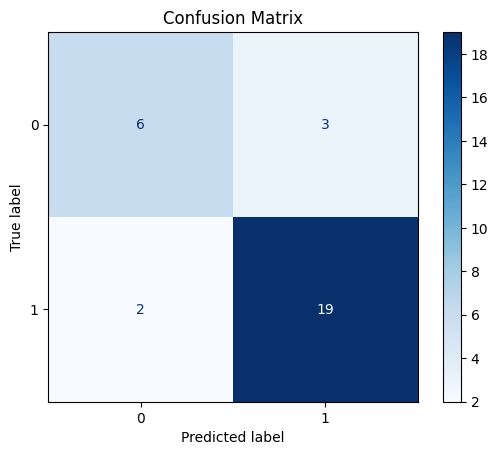


Precision and Recall Table:
 Class  Precision   Recall  F1-Score  Support
     0   0.750000 0.666667  0.705882        9
     1   0.863636 0.904762  0.883721       21


In [ ]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support
import matplotlib.pyplot as plt
import pandas as pd


# Example tensors
# y_actual = torch.tensor([...])
# y_predicted = torch.tensor([...])

# Convert tensors to NumPy arrays (if needed)
y_true = test_y_tensor.cpu().numpy()
y_pred = predicted.cpu().numpy()

# 1. Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# 2. Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

# 3. Precision, Recall, F1 Score
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, zero_division=0)

# Print as a table
metrics_df = pd.DataFrame({
    "Class": list(range(len(precision))),
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "Support": support
})

print("\nPrecision and Recall Table:")
print(metrics_df.to_string(index=False))


# Hinge Loss


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Sample dimensions

d = 8
n = num_timesteps
input_dim = 2 * d * n  # Flattened input size (16 * 96)


#train_x = torch.randn(batch_size, 2 * d, n)  # Shape: (999, 16, 152)
train_x = train_x.float()
#train_y = torch.randint(0, 2, (batch_size,))  # Binary labels for two classes
# Convert train_y from numpy array to torch tensor
train_y_tensor = torch.tensor(train_y, dtype=torch.long)  # Ensure the correct dtype for classification

# Define the model
class Classifier(nn.Module):
    def __init__(self, input_dim):
        super(Classifier, self).__init__()
        self.fc = nn.Linear(input_dim, 2)  # Fully connected layer for 2 classes

    def forward(self, x):
        #x = x.view(x.size(0), -1)  # Flatten 2*d x n to (batch_size, 2*d*n)
        x = x.reshape(x.size(0), -1)  # Flatten 2*d x n to (batch_size, 2*d*n)
        return self.fc(x)

# Instantiate the model
model = Classifier(input_dim)

# Loss and optimizer
#criterion = nn.CrossEntropyLoss()  # Use CrossEntropyLoss for binary classification
#optimizer = optim.Adam(model.parameters(), lr=0.1, weight_decay=0.1)
criterion = nn.MultiMarginLoss(margin=1.0)
optimizer = optim.Adam(model.parameters(), lr=0.001)


# Training loop
num_epochs = 40
for epoch in range(num_epochs):
    model.train()

    # Forward pass
    outputs = model(train_x)
    loss = criterion(outputs, train_y_tensor)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print loss
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/40], Loss: 0.4961
Epoch [2/40], Loss: 0.4584
Epoch [3/40], Loss: 0.4206
Epoch [4/40], Loss: 0.3829
Epoch [5/40], Loss: 0.3451
Epoch [6/40], Loss: 0.3087
Epoch [7/40], Loss: 0.2815
Epoch [8/40], Loss: 0.2696
Epoch [9/40], Loss: 0.2650
Epoch [10/40], Loss: 0.2635
Epoch [11/40], Loss: 0.2612
Epoch [12/40], Loss: 0.2574
Epoch [13/40], Loss: 0.2522
Epoch [14/40], Loss: 0.2460
Epoch [15/40], Loss: 0.2388
Epoch [16/40], Loss: 0.2311
Epoch [17/40], Loss: 0.2228
Epoch [18/40], Loss: 0.2138
Epoch [19/40], Loss: 0.2044
Epoch [20/40], Loss: 0.1946
Epoch [21/40], Loss: 0.1843
Epoch [22/40], Loss: 0.1747
Epoch [23/40], Loss: 0.1659
Epoch [24/40], Loss: 0.1576
Epoch [25/40], Loss: 0.1495
Epoch [26/40], Loss: 0.1436
Epoch [27/40], Loss: 0.1394
Epoch [28/40], Loss: 0.1365
Epoch [29/40], Loss: 0.1339
Epoch [30/40], Loss: 0.1316
Epoch [31/40], Loss: 0.1286
Epoch [32/40], Loss: 0.1247
Epoch [33/40], Loss: 0.1199
Epoch [34/40], Loss: 0.1151
Epoch [35/40], Loss: 0.1105
Epoch [36/40], Loss: 0.1061
E

/tmp/ipython-input-18307060.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_y_tensor = torch.tensor(train_y, dtype=torch.long)  # Ensure the correct dtype for classification


In [ ]:
#train_x = torch.randn(batch_size, 2 * d, n)  # Shape: (999, 16, 152)
test_x = test_x.float()
#train_y = torch.randint(0, 2, (batch_size,))  # Binary labels for two classes
# Convert train_y from numpy array to torch tensor
test_y_tensor = torch.tensor(test_y, dtype=torch.long)  # Ensure the correct dtype for classification
model.eval()
with torch.no_grad():
    # Ensure final_output is of float type


    # Perform inference
    outputs = model(test_x)  # Get the predictions
    _, predicted = torch.max(outputs, 1)  # Get the predicted class

    # Calculate accuracy
    accuracy = (predicted == test_y_tensor).sum().item() / test_y_tensor.size(0)
    print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 83.33%


/tmp/ipython-input-610142383.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_y_tensor = torch.tensor(test_y, dtype=torch.long)  # Ensure the correct dtype for classification


#Focal

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
# Sample dimensions

d = 8
n = num_timesteps
input_dim = 2 * d * n  # Flattened input size (16 * 96)


#train_x = torch.randn(batch_size, 2 * d, n)  # Shape: (999, 16, 152)
train_x = train_x.float()
#train_y = torch.randint(0, 2, (batch_size,))  # Binary labels for two classes
# Convert train_y from numpy array to torch tensor
train_y_tensor = torch.tensor(train_y, dtype=torch.long)  # Ensure the correct dtype for classification

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # inputs: raw logits (batch_size, 2), targets: class labels (batch_size,)
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')  # cross-entropy per sample
        pt = torch.exp(-ce_loss)  # get pt = softmax probability of the true class
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss  # no reduction


# Define the model
class Classifier(nn.Module):
    def __init__(self, input_dim):
        super(Classifier, self).__init__()
        self.fc = nn.Linear(input_dim, 2)  # Fully connected layer for 2 classes

    def forward(self, x):
        #x = x.view(x.size(0), -1)  # Flatten 2*d x n to (batch_size, 2*d*n)
        x = x.reshape(x.size(0), -1)  # Flatten 2*d x n to (batch_size, 2*d*n)
        return self.fc(x)

# Instantiate the model
model = Classifier(input_dim)

# Loss and optimizer
#criterion = nn.CrossEntropyLoss()  # Use CrossEntropyLoss for binary classification
#optimizer = optim.Adam(model.parameters(), lr=0.1, weight_decay=0.1)
criterion = nn.MultiMarginLoss(margin=1.0)
criterion = FocalLoss(alpha=1.0, gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)


# Training loop
num_epochs = 30
for epoch in range(num_epochs):
    model.train()

    # Forward pass
    outputs = model(train_x)
    loss = criterion(outputs, train_y_tensor)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print loss
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/30], Loss: 0.1763
Epoch [2/30], Loss: 0.1600
Epoch [3/30], Loss: 0.1472
Epoch [4/30], Loss: 0.1366
Epoch [5/30], Loss: 0.1274
Epoch [6/30], Loss: 0.1190
Epoch [7/30], Loss: 0.1112
Epoch [8/30], Loss: 0.1040
Epoch [9/30], Loss: 0.0975
Epoch [10/30], Loss: 0.0917
Epoch [11/30], Loss: 0.0865
Epoch [12/30], Loss: 0.0820
Epoch [13/30], Loss: 0.0780
Epoch [14/30], Loss: 0.0743
Epoch [15/30], Loss: 0.0709
Epoch [16/30], Loss: 0.0677
Epoch [17/30], Loss: 0.0647
Epoch [18/30], Loss: 0.0619
Epoch [19/30], Loss: 0.0592
Epoch [20/30], Loss: 0.0567
Epoch [21/30], Loss: 0.0543
Epoch [22/30], Loss: 0.0521
Epoch [23/30], Loss: 0.0500
Epoch [24/30], Loss: 0.0481
Epoch [25/30], Loss: 0.0463
Epoch [26/30], Loss: 0.0446
Epoch [27/30], Loss: 0.0429
Epoch [28/30], Loss: 0.0413
Epoch [29/30], Loss: 0.0399
Epoch [30/30], Loss: 0.0384


/tmp/ipython-input-2143739530.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_y_tensor = torch.tensor(train_y, dtype=torch.long)  # Ensure the correct dtype for classification


In [ ]:
#train_x = torch.randn(batch_size, 2 * d, n)  # Shape: (999, 16, 152)
test_x = test_x.float()
#train_y = torch.randint(0, 2, (batch_size,))  # Binary labels for two classes
# Convert train_y from numpy array to torch tensor
test_y_tensor = torch.tensor(test_y, dtype=torch.long)  # Ensure the correct dtype for classification
model.eval()
with torch.no_grad():
    # Ensure final_output is of float type


    # Perform inference
    outputs = model(test_x)  # Get the predictions
    _, predicted = torch.max(outputs, 1)  # Get the predicted class

    # Calculate accuracy
    accuracy = (predicted == test_y_tensor).sum().item() / test_y_tensor.size(0)
    print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 90.00%


/tmp/ipython-input-610142383.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_y_tensor = torch.tensor(test_y, dtype=torch.long)  # Ensure the correct dtype for classification
